In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime
import datetime as dt
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.dpi': 120,
    'figure.constrained_layout.use': True,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 16,
    'axes.labelsize': 10,
    'axes.labelcolor': '#444444',
    'axes.edgecolor': '#D6D6D6',
    'axes.linewidth': 0.7,
    'axes.axisbelow': True,
    'axes.prop_cycle': plt.cycler(color=['#68A66B', '#617D99', '#B49B65', '#8B819D']),
    'lines.linewidth': 1.5,
    'grid.color': '#E9E9E9',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.8,
    'xtick.color': '#666666',
    'ytick.color': '#666666',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'legend.fontsize': 9,
    'legend.loc': 'upper left',
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#DDDDDD',
    'legend.framealpha': 0.9,
    'legend.fancybox': False,
    'savefig.facecolor': 'white',
    'savefig.dpi': 180,
})


In [16]:
# Create the monthly data frame.
data = pd.DataFrame(index = pd.date_range(start='1970-01-01', end=datetime.now(), freq='MS'))

---
# Download gold and GLD data

In [17]:
# Download ETF prices.
ticker = "GLD"
gld = yf.download(ticker, start = "2000-01-01",interval = "1d",group_by = "Ticker",auto_adjust = True,progress = False)[ticker]
# Download historical gold prices.
gold = pd.read_csv("https://datahub.io/core/gold-prices/r/monthly.csv", parse_dates=['Date'], index_col='Date')

# Normalize datetime indices.
gld.index = pd.to_datetime(gld.index)
gld.index = gld.index.tz_localize(None)

gold.index = pd.to_datetime(gold.index)
gold.index = gold.index.tz_localize(None)
gold.index = gold.index.to_period('M').to_timestamp()


Check the correlation between gold and GLD returns over their shared history to evaluate whether spot gold provides a reasonable proxy for extending the historical return series

In [18]:
# Calculate monthly average ETF prices.
data_monthly_avg = gld.resample('ME').mean()

# Align the index to month starts.
data_monthly_avg.index = pd.to_datetime(data_monthly_avg.index)
data_monthly_avg.index = data_monthly_avg.index.tz_localize(None)
data_monthly_avg.index = data_monthly_avg.index.to_period('M').to_timestamp()

# Calculate returns for both series.
returns_df = gold['Price'].pct_change().dropna()
returns_gld = data_monthly_avg['Close'].pct_change().dropna()

# Combine the return series.
combined_returns = pd.concat([returns_df, returns_gld], axis=1)
combined_returns.columns = ['Gold_Returns', 'GLD_Returns']
combined_returns = combined_returns.dropna()

# Calculate the return correlation.
correlation_matrix = combined_returns.corr()
correlation_coefficient = correlation_matrix.loc['Gold_Returns', 'GLD_Returns']

print(f"Correlation coefficient between Gold Returns and GLD Returns: {correlation_coefficient:.4f}")

Correlation coefficient between Gold Returns and GLD Returns: 0.9970


Given the strong correlation, use spot gold returns for the earlier history, then ETF returns once available.

In [19]:
gld_daily = gld["Close"]
gld_monthly = gld_daily.resample('ME').last()

gld_monthly.index = gld_monthly.index.to_period('M').to_timestamp()

gold_ret = gold['Price'].pct_change()
gld_ret = gld_monthly.pct_change()
# Align datetime indices before combining the series.
#gold_ret.index = gold.index.to_timestamp()
#gld_ret.index = pd.to_datetime(gld_ret.index).tz_localize(None).to_period('M').to_timestamp()

# Join the two return histories.
first_gld_date = gld_ret.first_valid_index()
history_part = gold_ret[gold_ret.index <= first_gld_date]
history_part = history_part[history_part.index >= "1970-01-01"]
gld_part = gld_ret[gld_ret.index > first_gld_date]

# Store the combined returns in the data frame.
data["Gold_Return"] = pd.concat([history_part, gld_part])

---
# Download IEF and cash rate data

In [20]:
ticker = "IEF"
ief_daily_prices = yf.download(ticker, start = "2000-01-01",interval = "1d",group_by = "Ticker",auto_adjust = True, progress = False)[ticker]

# Download both Treasury yields to estimate bond prices.
start_date = '1969-12-31'
end_date = dt.date.today()

yields_daily = web.DataReader(['DGS7', 'DGS10'], 'fred', start_date, end_date)
yields_monthly = yields_daily.resample('ME').last()
yields_monthly.index = yields_monthly.index.to_period('M').to_timestamp()
# Download the cash rate.
fed_funds = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)

# Merge and label the yield and cash rate series.
bond_yield_data = pd.merge(yields_monthly, fed_funds, left_index=True, right_index=True, how='inner')
bond_yield_data.columns = ['Yield_7Y', 'Yield_10Y', 'Cash_Rate']

In [21]:
ESTIMATED_DURATION = 7.5  # Average duration for 7–10-year bonds
bond_yield_data['avg_yield'] = ((bond_yield_data['Yield_7Y'] + bond_yield_data['Yield_10Y']) / 2) / 100
bond_yield_data['delta_yield'] = bond_yield_data['avg_yield'].diff()
bond_yield_data['interest_income'] = bond_yield_data['avg_yield'].shift(1) / 12
bond_yield_data['price_change_contribution'] = -ESTIMATED_DURATION * bond_yield_data['delta_yield']
bond_yield_data['total_return'] = bond_yield_data['price_change_contribution'] + bond_yield_data['interest_income']
bond_yield_data['total_return'] = bond_yield_data['total_return'].fillna(0)
bond_yield_data['Synthetic_IEF'] = 100 * (1 + bond_yield_data['total_return']).cumprod()

Check the return correlation between IEF and the synthetic bond series.

In [22]:
data_synth = bond_yield_data[['Synthetic_IEF']].copy()
data_synth.columns = ['Synthetic']

data_real = ief_daily_prices[['Close']].copy().resample('ME').last().copy()

data_real.index = data_real.index.to_period('M').to_timestamp()

data_real.columns = ['Real_IEF']

# Align both indices to the same monthly timestamps.
data_synth.index = pd.to_datetime(data_synth.index)
data_real.index = pd.to_datetime(data_real.index)
data_synth.index = data_synth.index.tz_localize(None)
data_real.index = data_real.index.tz_localize(None)
data_synth.index = data_synth.index.to_period('M').to_timestamp()
data_real.index = data_real.index.to_period('M').to_timestamp()

comparison = pd.merge(data_synth, data_real, left_index=True, right_index=True, how='inner')

comparison['Synthetic_Return'] = comparison['Synthetic'].pct_change()
comparison['Actual_IEF_Return'] = comparison['Real_IEF'].pct_change()

comparison = comparison.dropna()

ief_return_correlation = comparison['Synthetic_Return'].corr(comparison['Actual_IEF_Return'])

print(f"Correlation between synthetic bond and IEF monthly returns over the shared history: {ief_return_correlation:.4f}")

Correlation between synthetic bond and IEF monthly returns over the shared history: 0.9910


Store the bond return series.

In [23]:
data["IEF_Return"] = data_synth.pct_change()
data["Cash_Rate"] = bond_yield_data["Cash_Rate"] / 100

---
# Gold Momentum as a standalone signal

Test whether positive gold momentum can serve as a timing signal for gold exposure at 1, 3, 6, and 12 month gold momentum lookbacks.

    Lookback  Total Return  Volatility    Sharpe
0   1 Months    614.220666    0.147843  0.838817
1   3 Months    238.995434    0.147288  0.727722
2   6 Months    295.809454    0.148640  0.748548
3  12 Months    614.383868    0.158631  0.792759


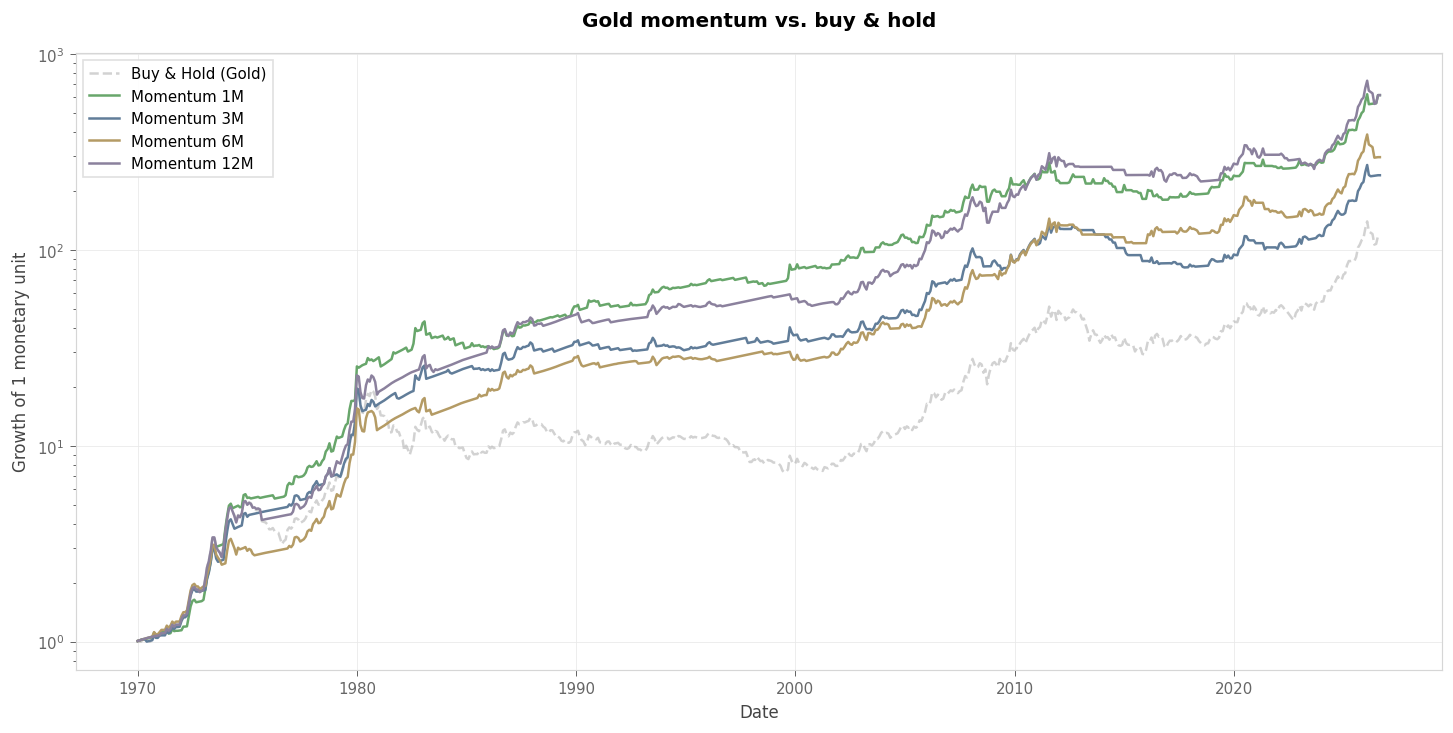

In [24]:

# Build the gold price index starting at 100.
data["Gold_Price"] = 100 * (1 + data["Gold_Return"]).cumprod()

# Momentum lookback periods.
lookback_periods = [1, 3, 6, 12]

# Data frame for equity curves.
equity_curves = pd.DataFrame(index=data.index)
equity_curves['Buy_and_Hold'] = (1 + data['Gold_Return'].fillna(0)).cumprod()

stats = []
for period in lookback_periods:
    signal_col = f'Signal_{period}M'

    momentum = data['Gold_Price'].pct_change(period).shift(1)

    data[signal_col] = np.where(momentum > 0, 1, 0)
    # Earn the cash return when the signal is zero; otherwise earn the gold return.
    strat_ret_col = f'Strat_{period}M'
    data[strat_ret_col] = (data[signal_col] * data['Gold_Return']) + \
                      ((1 - data[signal_col]) * (data['Cash_Rate'] / 12))

    # Build the equity curve.
    equity_curves[f'Momentum_{period}M'] = (1 + data[strat_ret_col].fillna(0)).cumprod()

    # Calculate performance statistics.
    total_ret = equity_curves[f'Momentum_{period}M'].iloc[-1] - 1
    vol = data[strat_ret_col].std() * (12**0.5) # Annualized
    sharpe = (data[strat_ret_col].mean() / data[strat_ret_col].std()) * (12**0.5)

    stats.append({
        'Lookback': f'{period} Months',
        'Total Return': total_ret,
        'Volatility': vol,
        'Sharpe': sharpe
    })

# --- DISPLAY RESULTS ---
results_df = pd.DataFrame(stats)
print(results_df)


plt.figure(figsize=(12, 6))

plt.plot(equity_curves['Buy_and_Hold'], label='Buy & Hold (Gold)', color='#A6A6A6', linestyle='--', alpha=0.5)

for period in lookback_periods:
    plt.plot(equity_curves[f'Momentum_{period}M'], label=f'Momentum {period}M')

plt.yscale('log') # Log scale for long-term growth.
plt.title('Gold momentum vs. buy & hold')
plt.xlabel('Date')
plt.ylabel('Growth of 1 monetary unit')
plt.legend()
plt.grid(True, which="major")
plt.show()

---
# Calculate the strategy using bond momentum as a cross asset signal

Test whether positive bond momentum can serve as a timing signal for gold exposure at the same four lookbacks.


/tmp/ipykernel_2846/3833889377.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bond_momentum = df_sim['IEF'].pct_change(period).shift(1)
/tmp/ipykernel_2846/3833889377.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bond_momentum = df_sim['IEF'].pct_change(period).shift(1)
/tmp/ipykernel_2846/3833889377.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bond_momentum = df_sim['IEF'].pct_c

  IEF Lookback  Total Return %  Volatility %  Sharpe
0     1 Months         4691.36         14.25    0.55
1     3 Months        10766.34         13.48    0.68
2     6 Months        22416.66         13.68    0.77
3    12 Months        13234.78         14.47    0.67


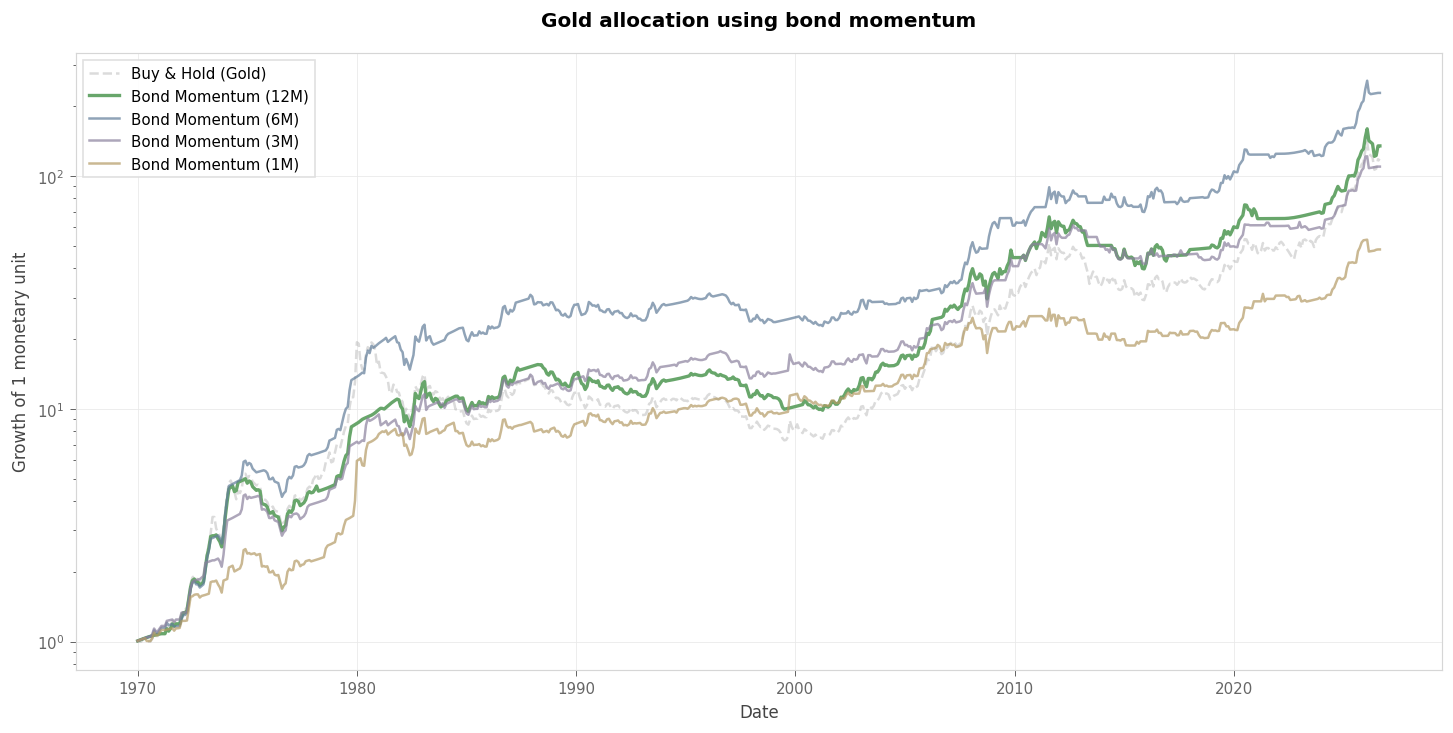

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_sim = data.copy()
df_sim['Gold_Price'] = 100 * (1 + df_sim['Gold_Return']).cumprod()
df_sim['IEF'] = 100 * (1 + df_sim['IEF_Return']).cumprod()
df_sim['Cash_Return_Monthly'] = df_sim['Cash_Rate'] / 12

lookback_periods = [1, 3, 6, 12]
stats = []
equity_curves = pd.DataFrame(index=df_sim.index)

equity_curves['Buy_and_Hold'] = (1 + df_sim['Gold_Return'].fillna(0)).cumprod()

for period in lookback_periods:
    bond_momentum = df_sim['IEF'].pct_change(period).shift(1)

    signal_col = f'Signal_Bond_{period}M'
    df_sim[signal_col] = np.where(bond_momentum > 0, 1, 0)

    strat_ret_col = f'Strat_BondPred_{period}M'

    df_sim[strat_ret_col] = (df_sim[signal_col] * df_sim['Gold_Return']) + \
                            ((1 - df_sim[signal_col]) * df_sim['Cash_Return_Monthly'])

    equity_curves[f'Bond_Predictor_{period}M'] = (1 + df_sim[strat_ret_col].fillna(0)).cumprod()

    total_ret = (equity_curves[f'Bond_Predictor_{period}M'].iloc[-1] / equity_curves[f'Bond_Predictor_{period}M'].iloc[0]) - 1
    vol = df_sim[strat_ret_col].std() * (12**0.5)
    sharpe = (df_sim[strat_ret_col].mean() / df_sim[strat_ret_col].std()) * (12**0.5)

    stats.append({
        'IEF Lookback': f'{period} Months',
        'Total Return %': round(total_ret * 100, 2),
        'Volatility %': round(vol * 100, 2),
        'Sharpe': round(sharpe, 2)
    })

print(pd.DataFrame(stats))

plt.figure(figsize=(12, 6))

plt.plot(equity_curves['Buy_and_Hold'], label='Buy & Hold (Gold)', color='#A6A6A6', linestyle='--', alpha=0.4)

plt.plot(equity_curves['Bond_Predictor_12M'], label='Bond Momentum (12M)', color='#68A66B', linewidth=2)
plt.plot(equity_curves['Bond_Predictor_6M'], label='Bond Momentum (6M)', color='#617D99', alpha=0.7)
plt.plot(equity_curves['Bond_Predictor_3M'], label='Bond Momentum (3M)', color='#8B819D', alpha=0.7)
plt.plot(equity_curves['Bond_Predictor_1M'], label='Bond Momentum (1M)', color='#B49B65', alpha=0.7)

plt.yscale('log')
plt.title('Gold allocation using bond momentum')
plt.xlabel('Date')
plt.ylabel('Growth of 1 monetary unit')
plt.legend()
plt.grid(True, which="major")
plt.show()

---
# Joint momentum strategy

Compare matching 1, 3, 6, and 12 month lookbacks for gold and bond momentum. Each variant allocates to gold only when both lagged momentum signals are positive and otherwise holds cash.


/tmp/ipykernel_2846/542777503.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_sim['Mom_Bond'] = df_sim['IEF'].pct_change(period).shift(1)
/tmp/ipykernel_2846/542777503.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_sim['Mom_Bond'] = df_sim['IEF'].pct_change(period).shift(1)
/tmp/ipykernel_2846/542777503.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_sim['Mom_Bond'] = df_sim[

             Strategy  Total Return %  CAGR %  Max DD %
0          Buy & Hold        11529.53    8.76    -62.07
1   Joint Momentum 1M        11540.76    8.76    -35.06
2   Joint Momentum 3M        11006.69    8.67    -37.34
3   Joint Momentum 6M        21448.80    9.95    -20.57
4  Joint Momentum 12M        51314.12   11.65    -28.47


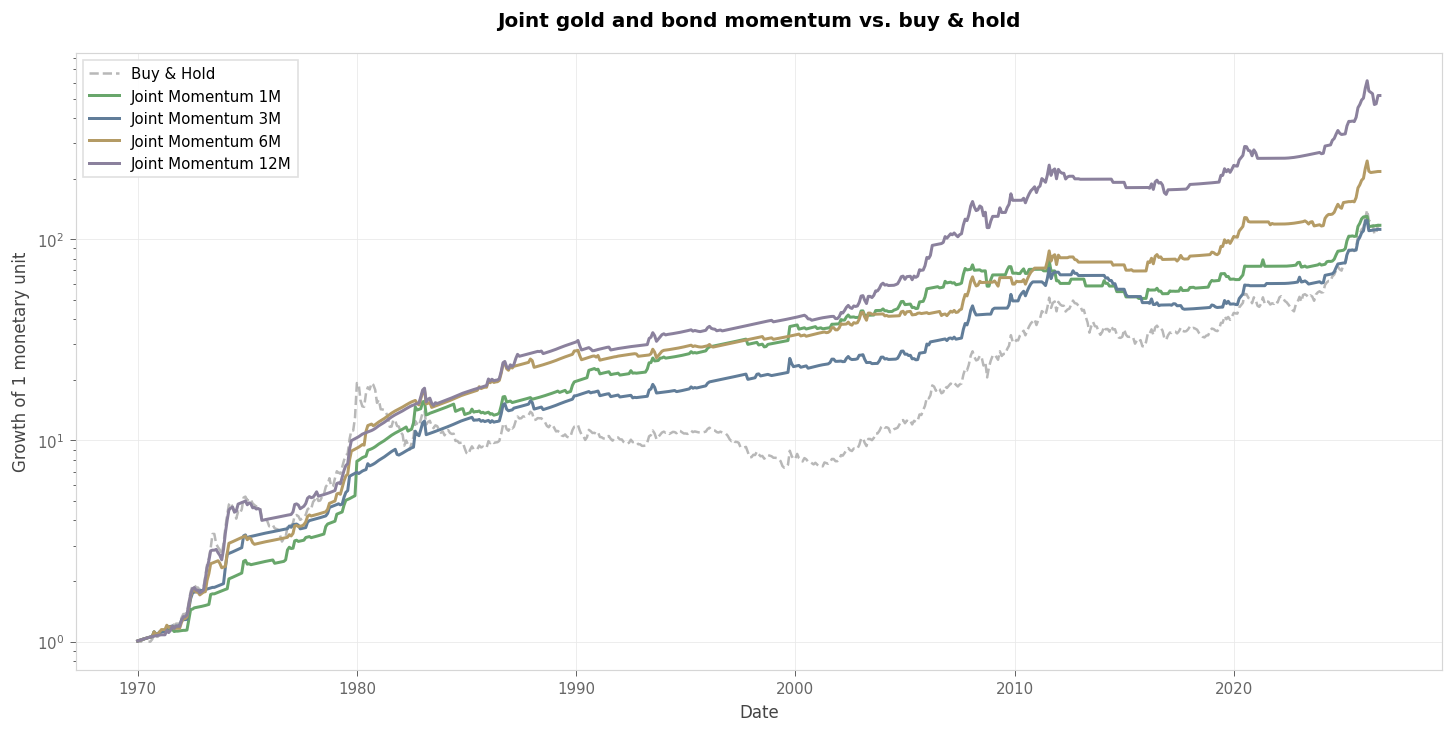

In [26]:
joint_lookback_periods = [1, 3, 6, 12]
df_sim = data.copy()

df_sim['Gold_Price'] = 100 * (1 + df_sim['Gold_Return']).cumprod()
df_sim['IEF'] = 100 * (1 + df_sim['IEF_Return']).cumprod()

df_sim['Cash_Return_Monthly'] = df_sim['Cash_Rate'] / 12

df_sim['Equity_BH'] = (1 + df_sim['Gold_Return'].fillna(0)).cumprod()

joint_equity_curves = pd.DataFrame(index=df_sim.index)

# Apply the same lookback to both signals for each variant.
for period in joint_lookback_periods:
    df_sim['Mom_Gold'] = df_sim['Gold_Price'].pct_change(period).shift(1)
    df_sim['Mom_Bond'] = df_sim['IEF'].pct_change(period).shift(1)

    df_sim['Signal_GoldOnly'] = np.where(df_sim['Mom_Gold'] > 0, 1, 0)

    df_sim['Signal_Joint'] = np.where((df_sim['Mom_Gold'] > 0) & (df_sim['Mom_Bond'] > 0), 1, 0)

    ret_joint = (df_sim['Signal_Joint'] * df_sim['Gold_Return']) + \
                ((1 - df_sim['Signal_Joint']) * df_sim['Cash_Return_Monthly'])
    df_sim['Equity_Joint'] = (1 + ret_joint.fillna(0)).cumprod()
    joint_equity_curves[f'Joint Momentum {period}M'] = df_sim['Equity_Joint']

def get_stats(equity_series, name):
    total_ret = (equity_series.iloc[-1] / equity_series.iloc[0]) - 1
    # Calculate CAGR using elapsed calendar years.
    years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25
    cagr = (equity_series.iloc[-1] / equity_series.iloc[0]) ** (1/years) - 1

    # Max Drawdown
    rolling_max = equity_series.cummax()
    drawdown = (equity_series - rolling_max) / rolling_max
    max_dd = drawdown.min()

    return {'Strategy': name, 'Total Return %': total_ret*100, 'CAGR %': cagr*100, 'Max DD %': max_dd*100}

stats_list = [get_stats(df_sim['Equity_BH'], 'Buy & Hold')]
for period in joint_lookback_periods:
    stats_list.append(get_stats(
        joint_equity_curves[f'Joint Momentum {period}M'],
        f'Joint Momentum {period}M'
    ))

# Full-history comparison; no lookback is selected automatically.
print(pd.DataFrame(stats_list).round(2))

plt.figure(figsize=(12, 6))
plt.plot(df_sim['Equity_BH'], label='Buy & Hold', color='#A6A6A6', linestyle='--', alpha=0.8)
for period in joint_lookback_periods:
    plt.plot(joint_equity_curves[f'Joint Momentum {period}M'],
             label=f'Joint Momentum {period}M', linewidth=1.8)

plt.yscale('log')
plt.title('Joint gold and bond momentum vs. buy & hold')
plt.xlabel('Date')
plt.ylabel('Growth of 1 monetary unit')
plt.legend()
plt.grid(True, which="major")
plt.show()

---

## Walk-forward backtest

The walk-forward procedure selects parameters using historical training windows. Each iteration selects the gold and IEF lookbacks with the highest training Sharpe ratio, then applies those parameters out of sample during the next test window.


Backtest metrics


,Strategy,CAGR %,Sharpe,Max Drawdown %,Calmar,Buys,Sells,Total Return %
0,Buy & Hold Gold,6.48,0.50,-42.91,0.15,0,0,888.37
1,Joint 12M Gold + IEF,7.98,0.71,-28.47,0.28,28,27,1550.40
2,Walk-Forward Joint,6.98,0.65,-25.83,0.27,36,36,1075.13


Latest walk-forward windows


,Test Start,Test End,Gold Lookback,IEF Lookback,Training Sharpe
17,2007-02-01,2008-01-01,9,12,1.03
18,2008-02-01,2009-01-01,12,12,1.09
19,2009-02-01,2010-01-01,6,12,0.87
20,2010-02-01,2011-01-01,6,12,0.95
21,2011-02-01,2012-01-01,12,6,0.92
22,2012-02-01,2013-01-01,6,12,0.91
23,2013-02-01,2014-01-01,6,12,0.84
24,2014-02-01,2015-01-01,6,12,0.80
25,2015-02-01,2016-01-01,6,12,0.78
26,2016-02-01,2017-01-01,6,12,0.75


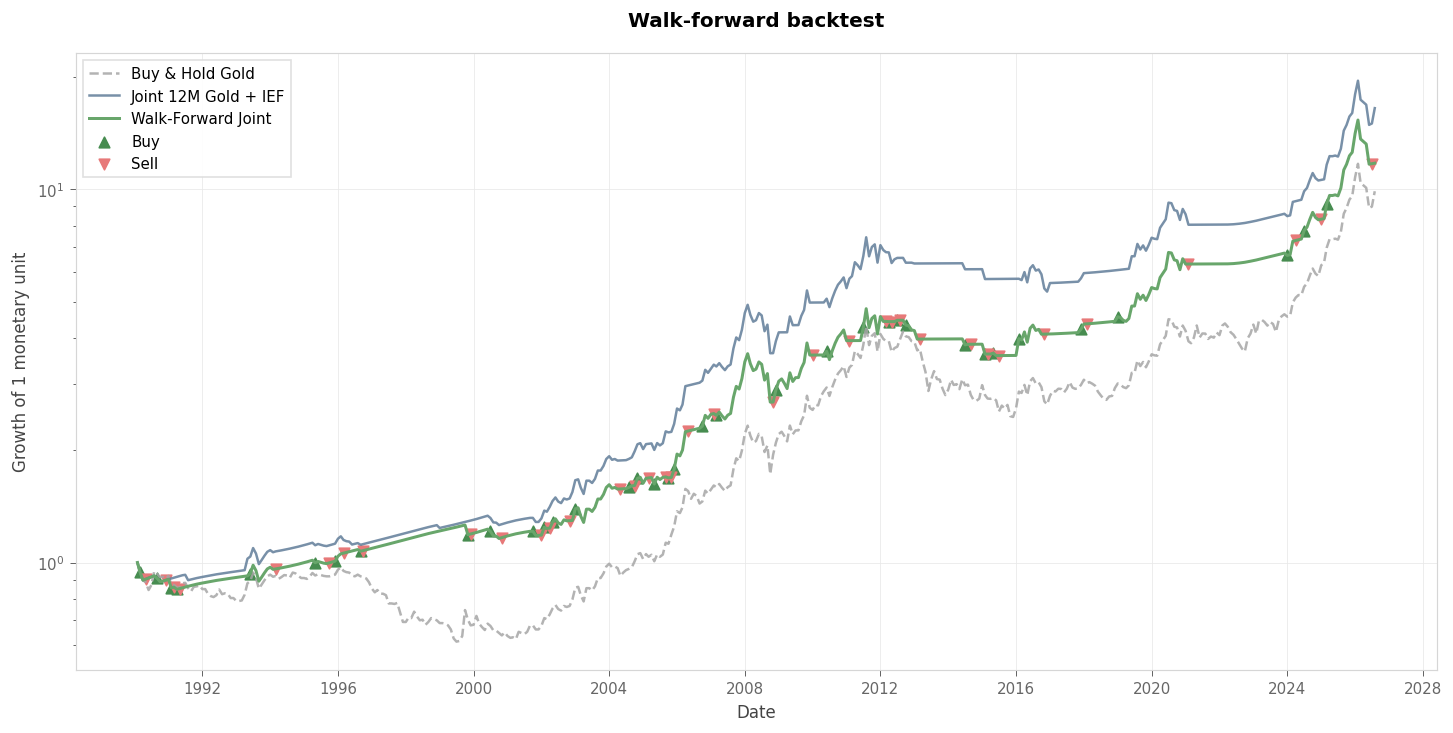

In [27]:
# Backtest: metrics, walk-forward analysis, and buy/sell signals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOOKBACK_CANDIDATES = [1, 3, 6, 9, 12]
TRAIN_YEARS = 20
TEST_MONTHS = 12
TRADING_MONTHS = 12


def prepare_backtest_data(raw_data):
    """Prepare the required series and remove months with insufficient data."""
    df = raw_data.copy()
    df['Gold_Return'] = df['Gold_Return'].astype(float)
    df['IEF_Return'] = df['IEF_Return'].astype(float)
    df['Cash_Return_Monthly'] = (df['Cash_Rate'].astype(float) / 12).fillna(0)
    df['Gold_Price'] = 100 * (1 + df['Gold_Return'].fillna(0)).cumprod()
    df['IEF_Price'] = 100 * (1 + df['IEF_Return'].fillna(0)).cumprod()
    return df.dropna(subset=['Gold_Return', 'IEF_Return', 'Cash_Return_Monthly', 'Gold_Price', 'IEF_Price'])


def build_joint_strategy(df, gold_lookback, bond_lookback):
    """Calculate gold/cash portfolio returns using gold and IEF momentum filters."""
    out = df.copy()
    out['Mom_Gold'] = out['Gold_Price'].pct_change(gold_lookback).shift(1)
    out['Mom_Bond'] = out['IEF_Price'].pct_change(bond_lookback).shift(1)
    out['Signal'] = np.where((out['Mom_Gold'] > 0) & (out['Mom_Bond'] > 0), 1, 0)
    out['Strategy_Return'] = (out['Signal'] * out['Gold_Return']) + ((1 - out['Signal']) * out['Cash_Return_Monthly'])
    out['Equity'] = (1 + out['Strategy_Return'].fillna(0)).cumprod()
    return out


def compute_metrics(returns, equity, signal=None, name='Strategy'):
    """Calculate annualized metrics and trade counts."""
    returns = returns.dropna()
    equity = equity.loc[returns.index].dropna()

    if len(equity) < 2:
        return {
            'Strategy': name, 'CAGR %': np.nan, 'Sharpe': np.nan, 'Max Drawdown %': np.nan,
            'Calmar': np.nan, 'Buys': 0, 'Sells': 0, 'Total Return %': np.nan
        }

    years = max((equity.index[-1] - equity.index[0]).days / 365.25, 1 / TRADING_MONTHS)
    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    sharpe = np.nan if returns.std() == 0 else (returns.mean() / returns.std()) * np.sqrt(TRADING_MONTHS)

    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()
    calmar = np.nan if max_drawdown == 0 else cagr / abs(max_drawdown)

    buys = sells = 0
    if signal is not None:
        signal = signal.loc[returns.index].fillna(0).astype(int)
        trades = signal.diff().fillna(signal.iloc[0])
        buys = int((trades == 1).sum())
        sells = int((trades == -1).sum())

    return {
        'Strategy': name,
        'CAGR %': cagr * 100,
        'Sharpe': sharpe,
        'Max Drawdown %': max_drawdown * 100,
        'Calmar': calmar,
        'Buys': buys,
        'Sells': sells,
        'Total Return %': total_return * 100
    }


def select_best_parameters(train_df, candidates):
    """Select the lookback pair with the highest training-period Sharpe ratio."""
    best_score = -np.inf
    best_params = (candidates[0], candidates[0])

    for gold_lb in candidates:
        for bond_lb in candidates:
            candidate = build_joint_strategy(train_df, gold_lb, bond_lb)
            valid_returns = candidate['Strategy_Return'].dropna()
            if valid_returns.std() == 0 or len(valid_returns) < max(gold_lb, bond_lb) + 2:
                score = -np.inf
            else:
                score = (valid_returns.mean() / valid_returns.std()) * np.sqrt(TRADING_MONTHS)

            if score > best_score:
                best_score = score
                best_params = (gold_lb, bond_lb)

    return best_params, best_score


def walk_forward_backtest(df, candidates, train_years=10, test_months=12):
    """Select parameters in a historical window and apply them out of sample."""
    train_months = train_years * TRADING_MONTHS
    wf = pd.DataFrame(index=df.index)
    wf['Strategy_Return'] = np.nan
    wf['Signal'] = np.nan
    wf['Gold_Lookback'] = np.nan
    wf['Bond_Lookback'] = np.nan
    windows = []

    start_pos = train_months
    while start_pos < len(df):
        end_pos = min(start_pos + test_months, len(df))
        train_df = df.iloc[start_pos - train_months:start_pos]
        test_idx = df.iloc[start_pos:end_pos].index

        best_params, train_sharpe = select_best_parameters(train_df, candidates)
        gold_lb, bond_lb = best_params
        full_candidate = build_joint_strategy(df, gold_lb, bond_lb)

        wf.loc[test_idx, 'Strategy_Return'] = full_candidate.loc[test_idx, 'Strategy_Return']
        wf.loc[test_idx, 'Signal'] = full_candidate.loc[test_idx, 'Signal']
        wf.loc[test_idx, 'Gold_Lookback'] = gold_lb
        wf.loc[test_idx, 'Bond_Lookback'] = bond_lb

        windows.append({
            'Test Start': test_idx[0],
            'Test End': test_idx[-1],
            'Gold Lookback': gold_lb,
            'IEF Lookback': bond_lb,
            'Training Sharpe': train_sharpe
        })
        start_pos = end_pos

    wf = wf.dropna(subset=['Strategy_Return'])
    wf['Equity'] = (1 + wf['Strategy_Return'].fillna(0)).cumprod()
    wf['Trade'] = wf['Signal'].diff().fillna(wf['Signal'].iloc[0])
    wf['Operation'] = np.select(
        [wf['Trade'] == 1, wf['Trade'] == -1],
        ['Buy', 'Sell'],
        default=''
    )
    return wf, pd.DataFrame(windows)


bt_data = prepare_backtest_data(data)

buy_hold_returns = bt_data['Gold_Return']
buy_hold_equity = (1 + buy_hold_returns.fillna(0)).cumprod()

static_joint = build_joint_strategy(bt_data, gold_lookback=12, bond_lookback=12)
walk_forward, wf_windows = walk_forward_backtest(
    bt_data,
    candidates=LOOKBACK_CANDIDATES,
    train_years=TRAIN_YEARS,
    test_months=TEST_MONTHS
)

common_idx = walk_forward.index

metrics = pd.DataFrame([
    compute_metrics(
        buy_hold_returns.loc[common_idx],
        buy_hold_equity.loc[common_idx] / buy_hold_equity.loc[common_idx].iloc[0],
        name='Buy & Hold Gold'
    ),
    compute_metrics(
        static_joint['Strategy_Return'].loc[common_idx],
        static_joint['Equity'].loc[common_idx] / static_joint['Equity'].loc[common_idx].iloc[0],
        static_joint['Signal'].loc[common_idx],
        'Joint 12M Gold + IEF'
    ),
    compute_metrics(
        walk_forward['Strategy_Return'],
        walk_forward['Equity'],
        walk_forward['Signal'],
        'Walk-Forward Joint'
    )
])


print('Backtest metrics')
display(metrics.round(2))

print('Latest walk-forward windows')
wf_windows_display = wf_windows.tail(20).copy()
wf_windows_display['Training Sharpe'] = wf_windows_display['Training Sharpe'].round(2)
display(wf_windows_display)

common_idx = walk_forward.index

bh_equity_norm = buy_hold_equity.loc[common_idx]
bh_equity_norm = bh_equity_norm / bh_equity_norm.iloc[0]

static_equity_norm = static_joint['Equity'].loc[common_idx]
static_equity_norm = static_equity_norm / static_equity_norm.iloc[0]

wf_equity_norm = walk_forward['Equity']
wf_equity_norm = wf_equity_norm / wf_equity_norm.iloc[0]

buys = walk_forward[walk_forward['Operation'] == 'Buy']
sells = walk_forward[walk_forward['Operation'] == 'Sell']

plt.figure(figsize=(12, 6))

plt.plot(common_idx, bh_equity_norm, '--', label='Buy & Hold Gold', color='#A6A6A6', alpha=0.85)
plt.plot(common_idx, static_equity_norm, label='Joint 12M Gold + IEF', color='#617D99', alpha=0.85)
plt.plot(common_idx, wf_equity_norm, label='Walk-Forward Joint', color='#68A66B', linewidth=1.8)

plt.scatter(buys.index, wf_equity_norm.loc[buys.index], marker='^', s=40, color='#478C50', label='Buy')
plt.scatter(sells.index, wf_equity_norm.loc[sells.index], marker='v', s=40, color='#E77979', label='Sell')

plt.yscale('log')
plt.title('Walk-forward backtest')
plt.ylabel('Growth of 1 monetary unit')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()


In [28]:
bt_data = prepare_backtest_data(data)
print("Backtest data start:", bt_data.index[0])
print("Number of months:", len(bt_data))

common_idx = walk_forward.index
print("Out-of-sample start:", common_idx[0])
print("Out-of-sample end:", common_idx[-1])
print("Out-of-sample years:", (common_idx[-1] - common_idx[0]).days / 365.25)

bh_eq = buy_hold_equity.loc[common_idx] / buy_hold_equity.loc[common_idx].iloc[0]
print("Initial buy-and-hold equity:", bh_eq.iloc[0])
print("Final buy-and-hold equity:", bh_eq.iloc[-1])
print("Buy-and-hold total return:", bh_eq.iloc[-1] - 1)

Backtest data start: 1970-02-01 00:00:00
Number of months: 679
Out-of-sample start: 1990-02-01 00:00:00
Out-of-sample end: 2026-08-01 00:00:00
Out-of-sample years: 36.49555099247091
Initial buy-and-hold equity: 1.0
Final buy-and-hold equity: 9.883690257630214
Buy-and-hold total return: 8.883690257630214
